In [55]:
library(dplyr)
library(ggplot2)
source("/mnt/lareaulab/reliscu/code/ggplot_theme.R")
theme_set(default_theme())

In [ ]:
files <- list.files(path = "data/ctype_exons", pattern = "exons.csv", full.names = TRUE, recursive = FALSE)

n_exons <- sapply(files, function(x) {
    df <- read.csv(x, stringsAsFactors = FALSE)
    nrow(df)
})

cell_types <- gsub("_", " ", gsub("_exons.csv", "", basename(files)))

df <- data.frame(cell_type = cell_types, n_exons = n_exons)

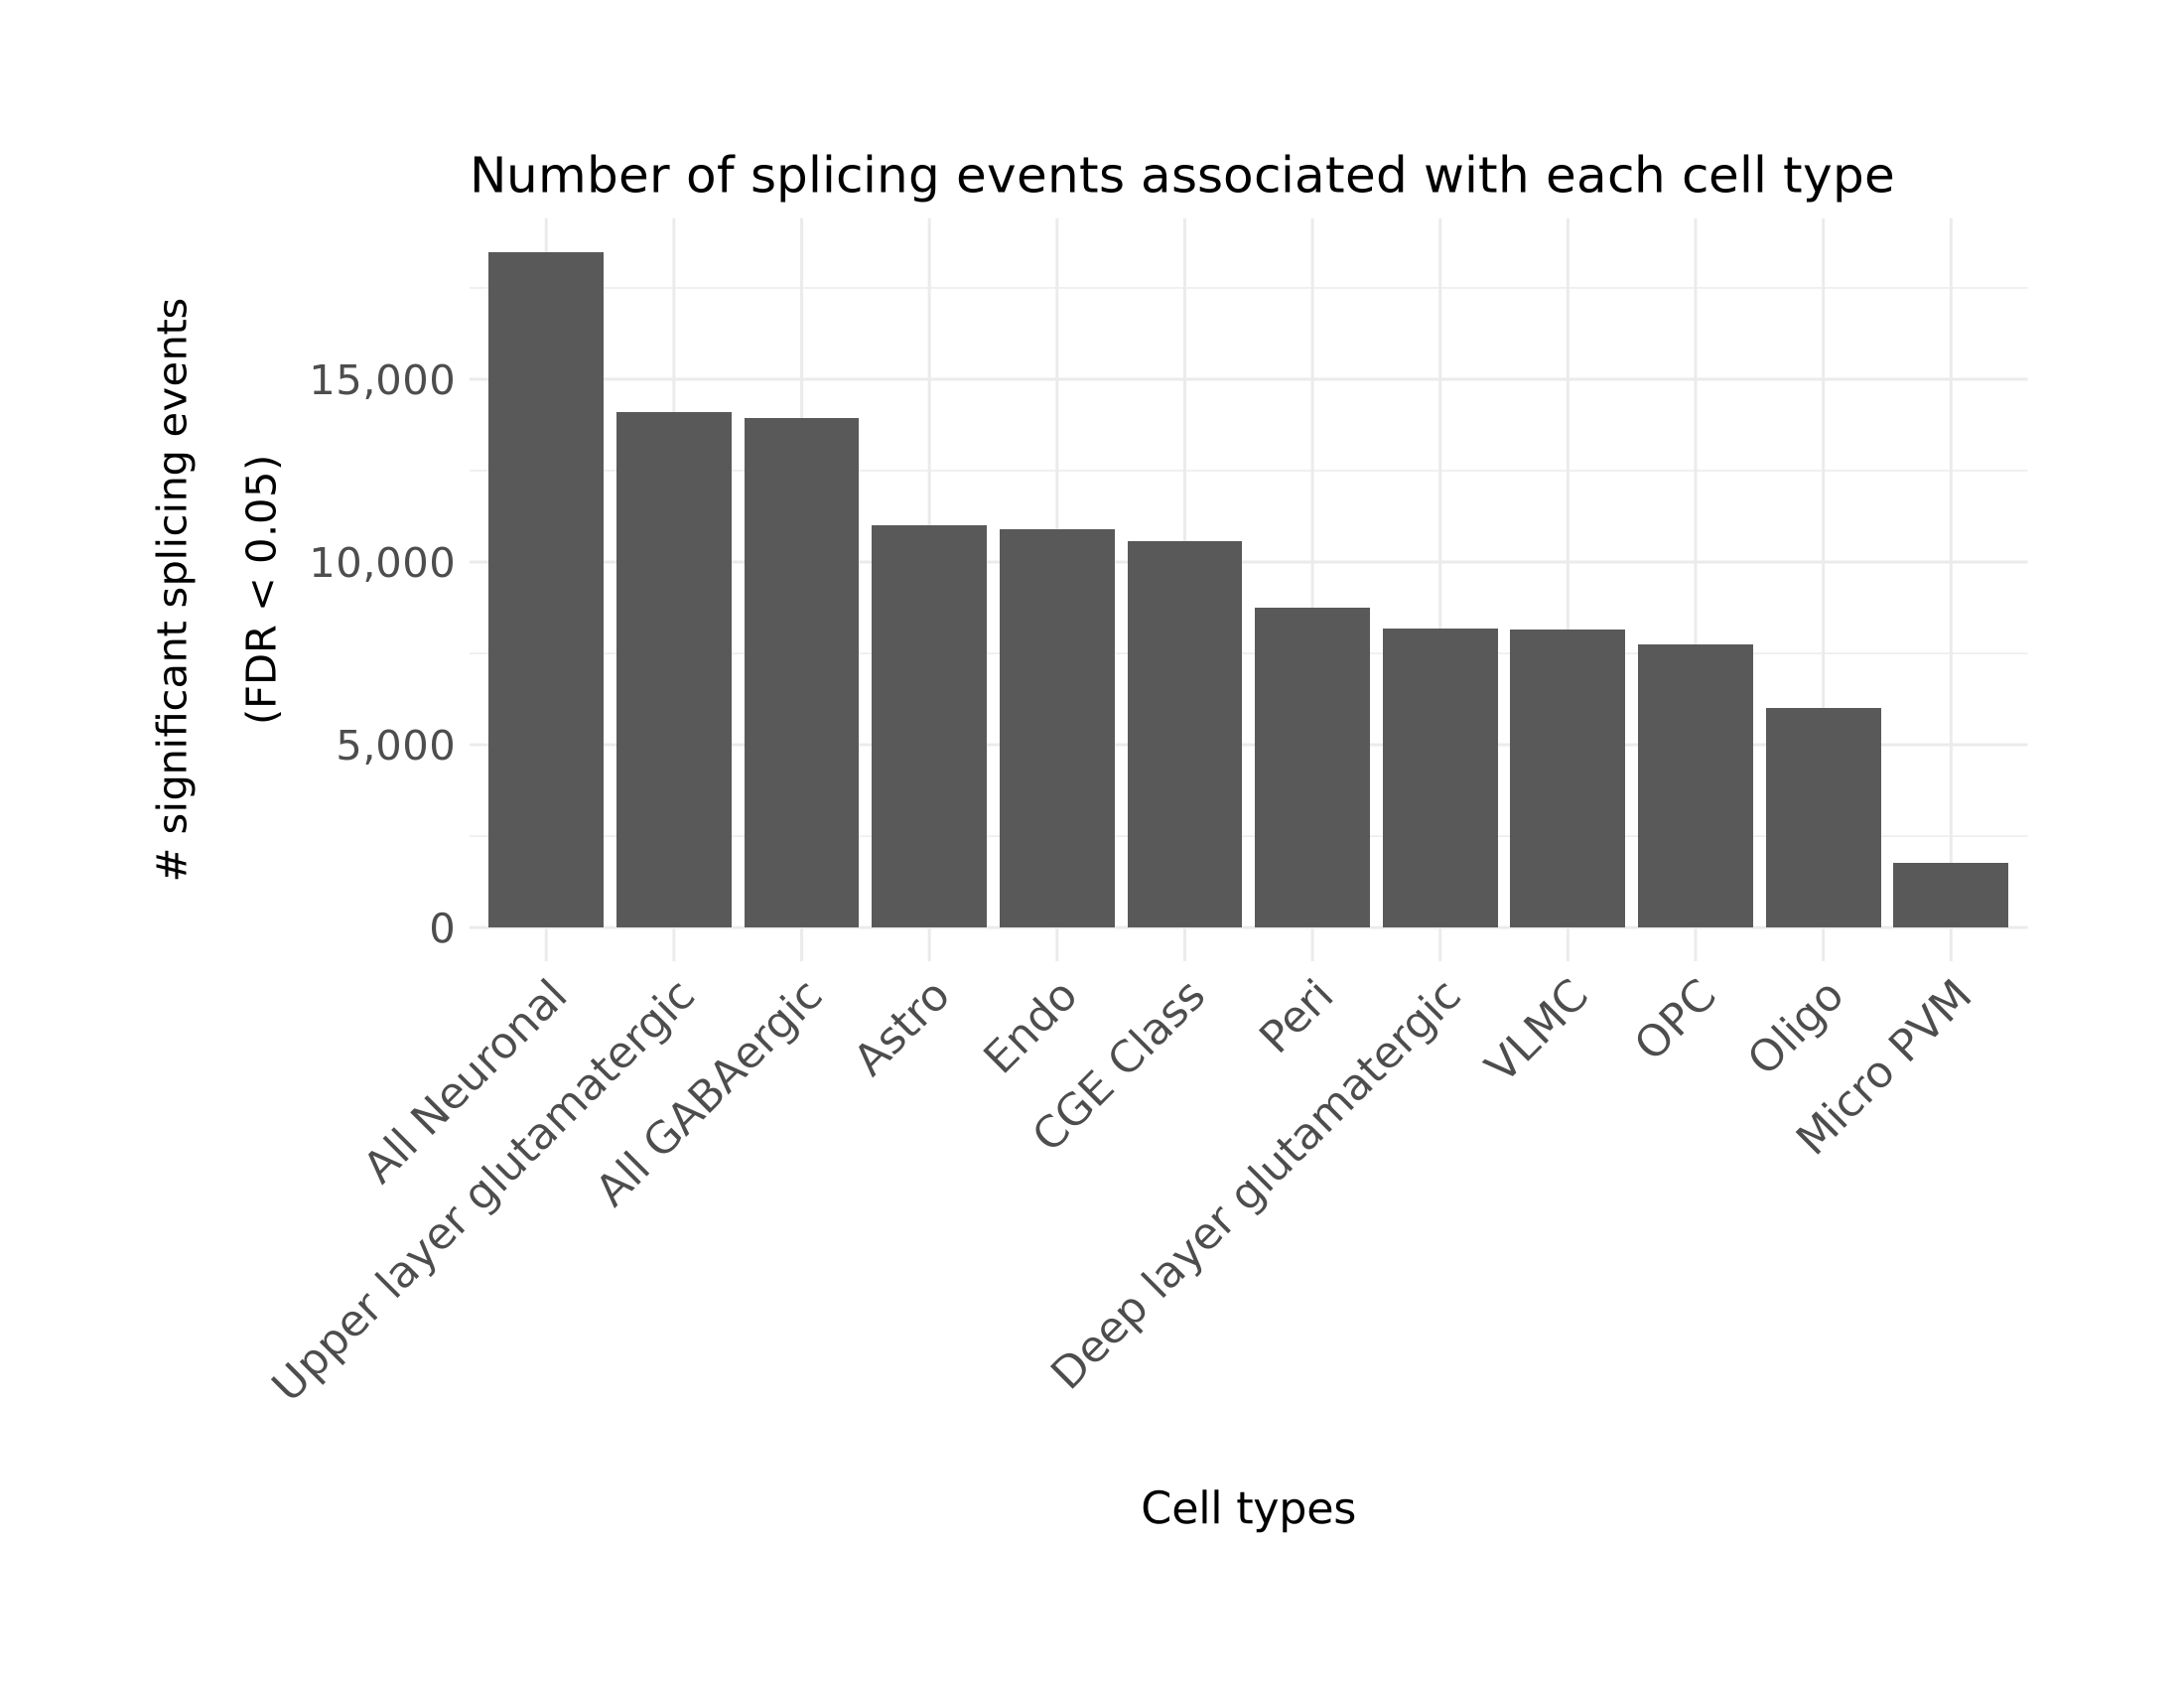

In [96]:
options(repr.plot.width=11, repr.plot.height=8.5, repr.plot.res=200)

ggplot(df, aes(x = reorder(cell_type, -n_exons), y = n_exons)) +
    geom_bar(stat = "identity") +
    theme(
        axis.text.x = element_text(angle=45, hjust=1, size=16),
        axis.text.y = element_text(size=15),
        axis.title.x = element_text(size=16),
        axis.title.y = element_text(size=15)
    ) +
    xlab("\nCell types") +
    ylab("# significant splicing events\n\n(FDR < 0.05)") +
    ggtitle("Number of splicing events associated with each cell type") +
    scale_y_continuous(labels = scales::comma)